<a href="https://colab.research.google.com/github/aesquivel94/operational-error-analyzer/blob/main/warehouse_operational_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Problem

Warehouse operations frequently experience recurring process errors that reduce through put and increase operational costs and time.

Examples include:
- Wrong item picked
- Missing item during packing
- Barcode scan failures
- Labeling errors (LPN)

While individual errors are tracked, organizations rarely analyze **error propagation patterns**, where one operational failure triggers additional downstream errors.

This project analyzes simulated warehouse operational data to identify:

1. The most frequent operational errors
2. Where errors occur in the workflow
3. Which errors generate the highest operational time loss
4. Recurring error chains across process steps

The goal is to demonstrate how data analysis can reveal systemic process failures and guide operational improvements.

# Methodology

This project uses a synthetic dataset designed to reflect realistic warehouse workflows.
The simulation includes:

- process-specific error probabilities
- root-cause mappings
- identifier types (SKU, barcode, LPN)
- estimated time impact
- recurring error chains



In [1]:
# rng = np.random.default_rng(42)

# Import packages for data simulation, analysis, and visualization

import numpy as np      # numerical operations and random simulation
import pandas as pd     # data manipulation and tabular analysis
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns   # statistical data visualization
import os               # file and directory management

# Set default visualization theme for cleaner charts
sns.set_theme(style="whitegrid")

## 2. Simulate Warehouse Error Data

This section generates a synthetic dataset representing operational errors in warehouse workflows.

The simulation includes:

-  process-specific error probabilities
- root cause categories
- identifier types (SKU, barcode, LPN)
- estimated operational impact in minutes


> This dataset is simulated for analytical demonstration purposes, based on realistic warehouse process patterns.


In [2]:
# Reproducible random generator
rng = np.random.default_rng(42)

# Number of simulated operational events
n = 400

# Core warehouse dimensions
shifts = ["A", "B", "C"]
process_steps = ["receiving", "picking", "packing", "back_to_stock"]
identifier_types = ["sku", "barcode", "lpn"]

# Core warehouse dimensions
step_error_weights = {
    "receiving": {
        "scan_failure": 0.35,
        "damage": 0.30,
        "lpn_error": 0.25,
        "missing_item": 0.10,
    },
    "picking": {
        "wrong_item": 0.35,
        "missing_item": 0.30,
        "lpn_error": 0.20,
        "scan_failure": 0.15,
    },
    "packing": {
        "wrong_item": 0.30,
        "damage": 0.25,
        "scan_failure": 0.25,
        "missing_item": 0.20,
    },
    "back_to_stock": {
        "missing_item": 0.35,
        "lpn_error": 0.30,
        "scan_failure": 0.20,
        "wrong_item": 0.15,
    },
}

# Possible operational root causes for each error type
error_to_root = {
    "wrong_item": ["incorrect_location", "training_gap", "mislabel"],
    "missing_item": ["inventory_mismatch", "incorrect_location", "system_lag"],
    "scan_failure": ["damaged_label", "system_lag", "mislabel"],
    "lpn_error": ["mislabel", "system_lag", "training_gap"],
    "damage": ["training_gap", "incorrect_location", "damaged_label"],
}

# Identifier systems associated with each error
error_to_identifier = {
    "wrong_item": ["sku", "barcode"],
    "missing_item": ["sku", "lpn"],
    "scan_failure": ["barcode", "lpn"],
    "lpn_error": ["lpn"],
    "damage": ["barcode", "sku"],
}

# Helper function to randomly select based on defined probabilities
def weighted_choice(options_dict):
    options = list(options_dict.keys())
    probs = list(options_dict.values())
    return rng.choice(options, p=probs)

# Generate random operational dates within a 90-day window
start = np.datetime64("2025-01-01")
dates = start + rng.integers(0, 90, size=n).astype("timedelta64[D]")

rows = []

# Simulate operational events
for i in range(n):

    # Assign operational context
    shift = rng.choice(shifts, p=[0.36, 0.34, 0.30])
    step = rng.choice(process_steps, p=[0.20, 0.35, 0.25, 0.20])

    # Generate error characteristics
    error_type = weighted_choice(step_error_weights[step])
    root_cause = rng.choice(error_to_root[error_type])
    identifier_type = rng.choice(error_to_identifier[error_type])

    # Operational impact simulation (skewed distribution)
    base = rng.gamma(shape=2.0, scale=7.0)

    multiplier = {
        "missing_item": 1.4,
        "wrong_item": 1.3,
        "lpn_error": 1.2,
        "scan_failure": 1.0,
        "damage": 1.1,
    }[error_type]

    impact_minutes = int(round(base * multiplier))

    rows.append([
        str(dates[i]),
        shift,
        step,
        error_type,
        root_cause,
        identifier_type,
        impact_minutes
    ])

# Build final dataset
df = pd.DataFrame(rows, columns=[
    "date",
    "shift",
    "process_step",
    "error_type",
    "root_cause",
    "identifier_type",
    "impact_minutes"
])

df.head()

,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19


# Data Check

This section verifies dataset structure and validates the generated variables.

In [3]:
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             400 non-null    object
 1   shift            400 non-null    object
 2   process_step     400 non-null    object
 3   error_type       400 non-null    object
 4   root_cause       400 non-null    object
 5   identifier_type  400 non-null    object
 6   impact_minutes   400 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 22.0+ KB


,impact_minutes
count,400.000000
mean,17.162500
std,12.176278
min,1.000000
25%,8.750000
50%,15.000000
75%,23.000000
max,75.000000


# Error Frequency Analysis

Question answered:

**Which errors happen most often?**

Chart - This shows basic operational insight.

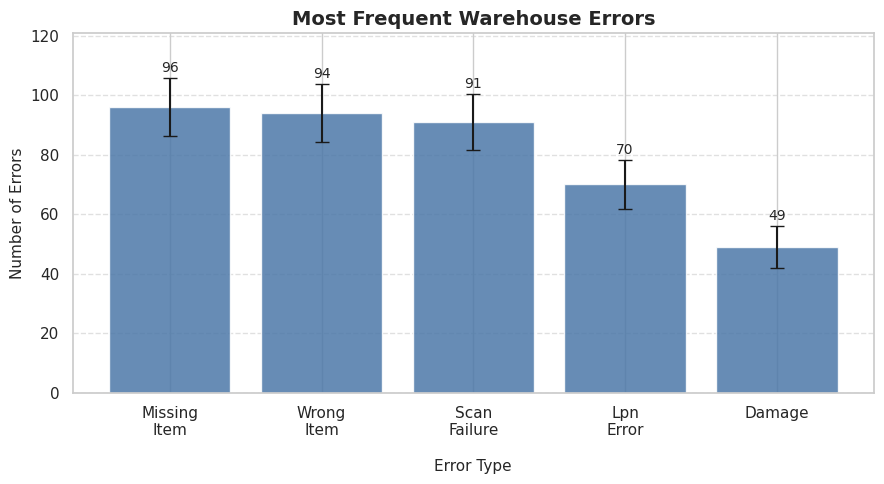

In [4]:
error_counts = df["error_type"].value_counts()

def format_label(text):
    words = text.replace("_", " ").title().split()

    if len(words) == 2:
        return f"{words[0]}\n{words[1]}"

    return "\n".join(words)

labels = [format_label(x) for x in error_counts.index]
error = np.sqrt(error_counts.values)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    labels,
    error_counts.values,
    yerr=error,
    capsize=5,
    color="#4C78A8",   # colorblind-friendly blue
    alpha=0.85
)

# Add value labels above the error bars
for i, v in enumerate(error_counts.values):
    plt.text(
        i,
        v + error[i] + 2,   # bar height + error bar + padding
        str(v),
        ha="center",
        fontsize=10
    )

plt.title("Most Frequent Warehouse Errors", fontsize=14, weight="bold")
plt.ylabel("Number of Errors", fontsize=11)
plt.xlabel("Error Type", fontsize=11, labelpad=15)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.ylim(0, max(error_counts.values + error) + 15)
plt.tight_layout()
plt.show()

In [5]:
total_errors = len(df)
total_minutes = df["impact_minutes"].sum()
top_error = df["error_type"].value_counts().idxmax().replace("_", " ").title()
top_impact = df.groupby("error_type")["impact_minutes"].sum().idxmax().replace("_", " ").title()

print("Total Errors:", total_errors)
print("Total Minutes Lost:", total_minutes)
print("Most Frequent Error:", top_error)
print("Highest-Impact Error:", top_impact)

Total Errors: 400
Total Minutes Lost: 6865
Most Frequent Error: Missing Item
Highest-Impact Error: Missing Item


# Errors by Process Step

Question answered: Where do errors occur in the workflow?

- picking generates most wrong-item errors

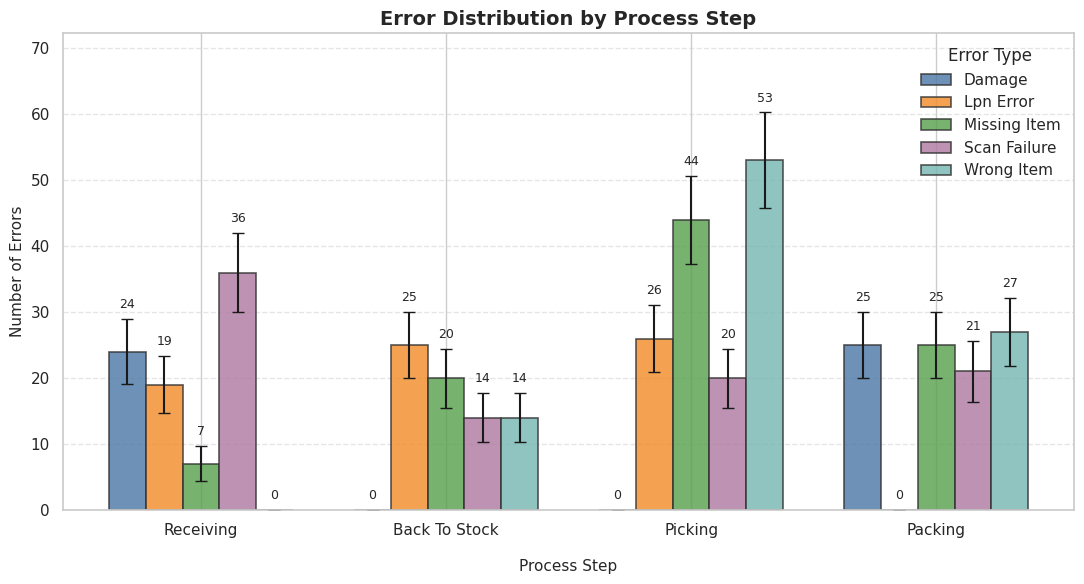

In [6]:
# Second Analysis: Errors by Process Step
step_errors = pd.crosstab(df["process_step"], df["error_type"])

# Force process order
process_order = ["receiving", "back_to_stock", "picking", "packing"]
step_errors = step_errors.loc[process_order]

# Format labels
x_labels = [x.replace("_", " ").title() for x in step_errors.index]
legend_labels = [x.replace("_", " ").title() for x in step_errors.columns]

# Colorblind-friendly palette (Okabe-Ito inspired)
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#B07AA1", "#76B7B2"]
plt.figure(figsize=(11, 6))

x = np.arange(len(step_errors.index))
width = 0.15

for i, col in enumerate(step_errors.columns):
    values = step_errors[col].values
    errors = np.sqrt(values)  # simple count-based approximation

    bars = plt.bar(
        x + i * width,
        values,
        width=width,
        yerr=errors,
        capsize=4,
        label=legend_labels[i],
        color=colors[i],
        alpha=0.82,
        edgecolor="#33333333",
        linewidth=1.2
    )

    # Add value labels above the error bars
    for j, v in enumerate(values):
        plt.text(
            x[j] + i * width,
            v + errors[j] + 1.2,
            str(v),
            ha="center",
            va="bottom",
            fontsize=9
        )

# Center x tick labels
plt.xticks(
    x + width * (len(step_errors.columns) - 1) / 2,
    x_labels
)

plt.title("Error Distribution by Process Step", fontsize=14, weight="bold")
plt.ylabel("Number of Errors", fontsize=11)
plt.xlabel("Process Step", fontsize=11, labelpad=15)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Error Type", frameon=False)

# Add top space so labels don't get cramped
plt.ylim(0, (step_errors.values.max() + np.sqrt(step_errors.values.max()) + 12))

plt.tight_layout()
plt.show()

# Operational Impact Analysis

Question answered - Which operational errors generate the greatest time loss?

Error frequency alone does not fully describe operational impact.
Some errors occur less frequently but result in longer recovery time, additional handling, or workflow disruptions.

This analysis estimates the total operational time lost per error type in order to identify the most costly failures in the process.

Because frequency ≠ impact.

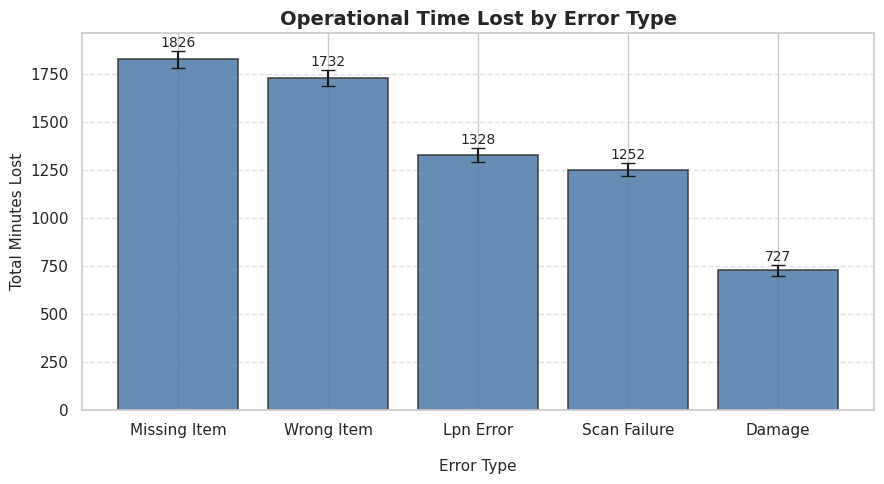

In [7]:
cost_analysis = (
    df.groupby("error_type")["impact_minutes"]
    .sum()
    .sort_values(ascending=False)
)

# Format labels
labels = [x.replace("_", " ").title() for x in cost_analysis.index]

# Error bars (simple approximation)
error = np.sqrt(cost_analysis.values)

plt.figure(figsize=(9,5))

bars = plt.bar(
    labels,
    cost_analysis.values,
    yerr=error,
    capsize=5,
    color="#4E79A7",   # colorblind-friendly
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Value labels above error bars
for i, v in enumerate(cost_analysis.values):
    plt.text(
        i,
        v + error[i] + 20,
        str(v),
        ha="center",
        fontsize=10
    )

plt.title("Operational Time Lost by Error Type", fontsize=14, weight="bold")
plt.ylabel("Total Minutes Lost", fontsize=11)
plt.xlabel("Error Type", fontsize=11, labelpad=15)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Recurring Error Chains

Question answered:
Which operational errors tend to trigger other errors?

Operational failures rarely occur in isolation.
One process breakdown can propagate downstream and generate additional errors.

This analysis identifies recurring error chains, helping reveal systemic weaknesses in the workflow.

Understanding these patterns allows operations teams to target root causes instead of isolated symptoms.

In [8]:
# Create a simple previous_error column to simulate error chains
possible_previous = {
    "wrong_item": {
        "scan_failure": 0.5,
        "lpn_error": 0.3,
        "missing_item": 0.2
    },
    "missing_item": {
        "wrong_item": 0.4,
        "scan_failure": 0.4,
        "lpn_error": 0.2
    },
    "lpn_error": {
        "scan_failure": 0.6,
        "wrong_item": 0.4
    },
    "scan_failure": {
        "no_previous": 1.0
    }
}

def sample_previous_error(x):
    options = possible_previous.get(x, {"no_previous": 1.0})

    errors = list(options.keys())
    probs = list(options.values())

    return rng.choice(errors, p=probs)

# print(df["error_type"].unique())
# missing_keys = set(df["error_type"].unique()) - set(possible_previous.keys())
# print(missing_keys)

df["previous_error"] = df["error_type"].apply(sample_previous_error)
df.head()


,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes,previous_error
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18,scan_failure
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7,scan_failure
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12,no_previous
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22,missing_item
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19,scan_failure


In [9]:
# Save Dataset
os.makedirs("../data", exist_ok=True)

df.to_csv("../data/bts_errors.csv", index=False)
print("Saved:", df.shape)

Saved: (400, 8)


In [10]:
chain_counts = (
    df.groupby(["previous_error", "error_type"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

sankey_data = chain_counts.head(12).copy()
chain_counts.head(10)

,previous_error,error_type,count
4,no_previous,scan_failure,91
3,no_previous,damage,49
5,scan_failure,lpn_error,46
7,scan_failure,wrong_item,41
6,scan_failure,missing_item,38
9,wrong_item,missing_item,35
1,lpn_error,wrong_item,32
8,wrong_item,lpn_error,24
0,lpn_error,missing_item,23
2,missing_item,wrong_item,21


In [11]:
# -----------------------------
# Sankey diagram of error flows
# -----------------------------
# This visualization shows how one error can lead to another,
# making downstream failure patterns easier to understand.

import plotly.graph_objects as go

# Use the most frequent chains for a clearer diagram
sankey_data = chain_counts.head(12).copy()

# Create labels for all unique nodes
all_nodes = pd.unique(
    sankey_data[["previous_error", "error_type"]].values.ravel()
)

# Format node labels for display
node_labels = [x.replace("_", " ").title() for x in all_nodes]

# Map each node name to an index
node_index = {node: i for i, node in enumerate(all_nodes)}

# Create source-target links
sources = sankey_data["previous_error"].map(node_index)
targets = sankey_data["error_type"].map(node_index)
values = sankey_data["count"]

# Build Sankey figure
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color="#4E79A7"
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(78, 121, 167, 0.35)"
    )
)])

fig.update_layout(
    title_text="Flow of Recurring Warehouse Error Chains",
    font=dict(size=11),
    height=500
)

fig.show()

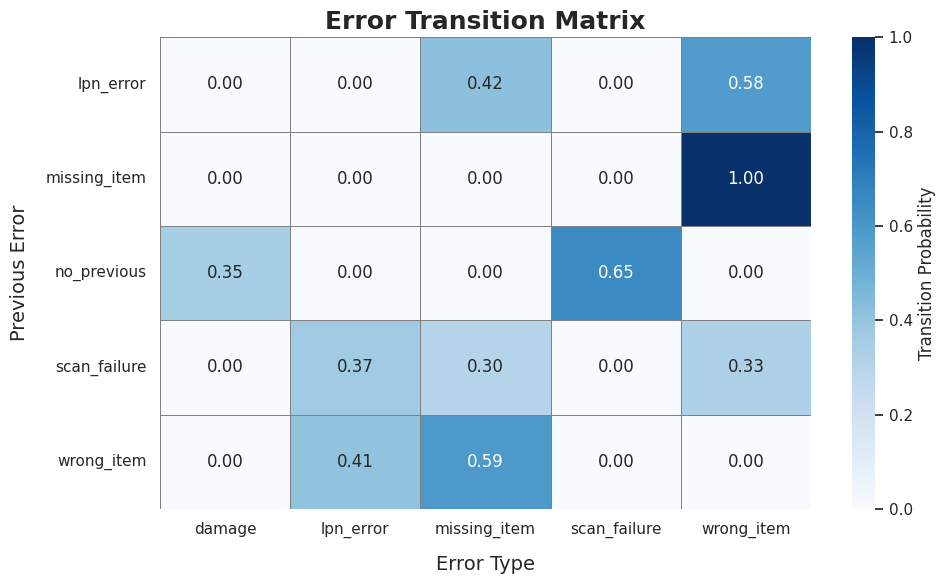

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

transition_matrix = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .unstack(fill_value=0)
)

transition_matrix = transition_matrix.div(
    transition_matrix.sum(axis=1),
    axis=0
)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    transition_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Transition Probability"},
    ax=ax
)

ax.set_title("Error Transition Matrix", fontsize=18, weight="bold")
ax.set_xlabel("Error Type", fontsize=14, labelpad=12)
ax.set_ylabel("Previous Error", fontsize=14, labelpad=12)

ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()
plt.show()

# Visualizing Error Propagation

To better understand how failures move through the workflow, a Sankey diagram is used to represent recurring error chains.

This helps highlight which upstream problems are most likely to contribute to downstream operational failures.

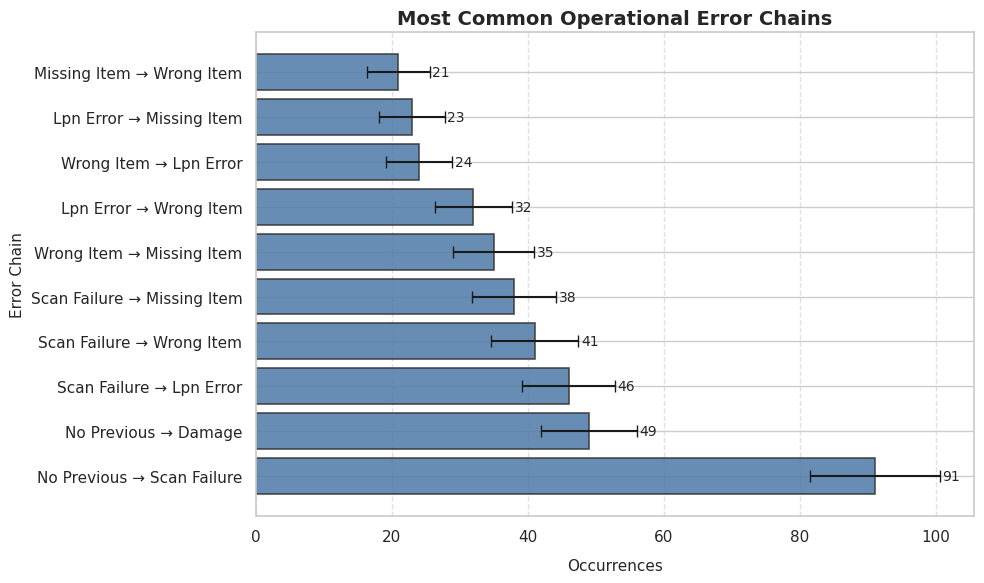

In [13]:
# -----------------------------------------
# Horizontal bar chart of top recurring chains
# -----------------------------------------
# This chart ranks the most common error-to-error sequences.

# Format chain labels for readability
sankey_data["chain"] = (
    sankey_data["previous_error"].str.replace("_", " ").str.title()
    + " → " +
    sankey_data["error_type"].str.replace("_", " ").str.title()
)

values = sankey_data["count"].values
error = np.sqrt(values)  # simple count-based approximation for intervals

plt.figure(figsize=(10, 6))

plt.barh(
    sankey_data["chain"],
    values,
    xerr=error,
    capsize=4,
    color="#4E79A7",
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Add labels at the end of each bar
for i, v in enumerate(values):
    plt.text(
        v + error[i] + 0.4,
        i,
        str(v),
        va="center",
        fontsize=10
    )

plt.title("Most Common Operational Error Chains", fontsize=14, weight="bold")
plt.xlabel("Occurrences", fontsize=11, labelpad=10)
plt.ylabel("Error Chain", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
transition_matrix = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .unstack(fill_value=0)
)

# Convert to probabilities
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

transition_matrix

# This is real-world operations modeling
# You’re now extracting behavior patterns from data
# This is the foundation of Markov Chains

error_type,damage,lpn_error,missing_item,scan_failure,wrong_item
previous_error,,,,,
lpn_error,0.00,0.00000,0.418182,0.00,0.581818
missing_item,0.00,0.00000,0.000000,0.00,1.000000
no_previous,0.35,0.00000,0.000000,0.65,0.000000
scan_failure,0.00,0.36800,0.304000,0.00,0.328000
wrong_item,0.00,0.40678,0.593220,0.00,0.000000


# Simulate Error Chains (Markov Thinking)

In [15]:
def simulate_chain(start_error, steps=5):
    current = start_error
    chain = [current]

    for _ in range(steps):
        if current not in transition_matrix.index:
            break

        probs = transition_matrix.loc[current]
        next_error = rng.choice(probs.index, p=probs.values)

        chain.append(next_error)
        current = next_error

    return chain

simulate_chain("scan_failure")

# “If this error happens… what tends to happen next?”
# That’s predictive process behavior

['scan_failure',
 np.str_('lpn_error'),
 np.str_('wrong_item'),
 np.str_('missing_item'),
 np.str_('wrong_item'),
 np.str_('lpn_error')]

In [16]:
chain_counts = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

chain_counts.head(10)

# “These are the most common failure sequences in operations.”

,previous_error,error_type,count
4,no_previous,scan_failure,91
3,no_previous,damage,49
5,scan_failure,lpn_error,46
7,scan_failure,wrong_item,41
6,scan_failure,missing_item,38
9,wrong_item,missing_item,35
1,lpn_error,wrong_item,32
8,wrong_item,lpn_error,24
0,lpn_error,missing_item,23
2,missing_item,wrong_item,21


In [17]:
error_impact = {
    "wrong_item": 5,
    "missing_item": 8,
    "lpn_error": 6,
    "scan_failure": 4
}

df["error_cost"] = df["error_type"].map(error_impact)

impact_by_chain = (
    df.groupby(["previous_error", "error_type"])["error_cost"]
    .sum()
    .reset_index()
    .sort_values(by="error_cost", ascending=False)
)

impact_by_chain.head(10)

# “These chains are not just frequent — they are expensive.”

,previous_error,error_type,error_cost
4,no_previous,scan_failure,364.0
6,scan_failure,missing_item,304.0
9,wrong_item,missing_item,280.0
5,scan_failure,lpn_error,276.0
7,scan_failure,wrong_item,205.0
0,lpn_error,missing_item,184.0
1,lpn_error,wrong_item,160.0
8,wrong_item,lpn_error,144.0
2,missing_item,wrong_item,105.0
3,no_previous,damage,0.0


In [18]:
df["risk_score"] = df["error_cost"] + df["previous_error"].map(error_impact).fillna(0)
# rank risky orders
# identify problematic workflows

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Example features
features = ["process_step"]
X = pd.get_dummies(df[features])
y = df["error_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))
# “I can predict operational errors before they happen.”

Accuracy: 0.275


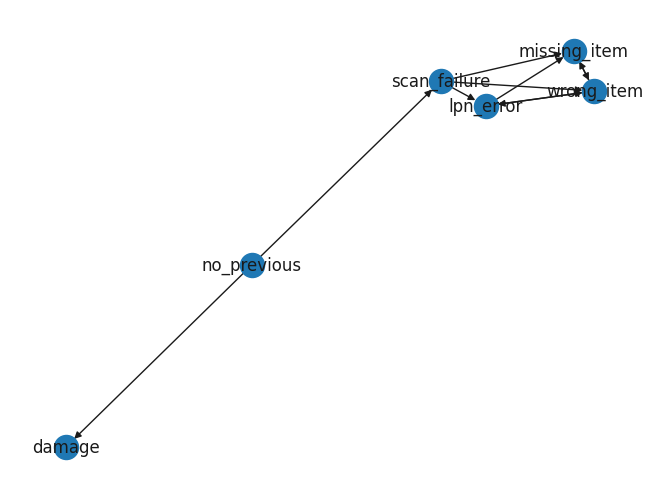

In [20]:
import networkx as nx

G = nx.from_pandas_edgelist(
    chain_counts,
    source="previous_error",
    target="error_type",
    edge_attr="count",
    create_using=nx.DiGraph()
)

nx.draw(G, with_labels=True)

# your system is a failure network


> “I built a system to analyze and model operational error propagation using Python.
I identified high-risk failure chains, quantified their impact, and simulated future error scenarios to support process improvement decisions.”




## Key Insight

The analysis suggests that upstream identification problems,
particularly **barcode scan failures**, frequently trigger
downstream operational issues such as:

- Wrong item selection
- Missing items during packing
- Labeling errors

This indicates that improving **early-stage scanning reliability**
could significantly reduce downstream operational errors.

Potential operational interventions:

• Improve barcode scanning hardware reliability  
• Introduce scan validation checkpoints  
• Provide targeted training for high-error workflow steps  

Reducing upstream scan failures may prevent entire error chains,
improving throughput and operational efficiency.
